# Business Insight / Time Series Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/clean/clean_data.csv")

## -Order per month 2023 (Most Data Set)

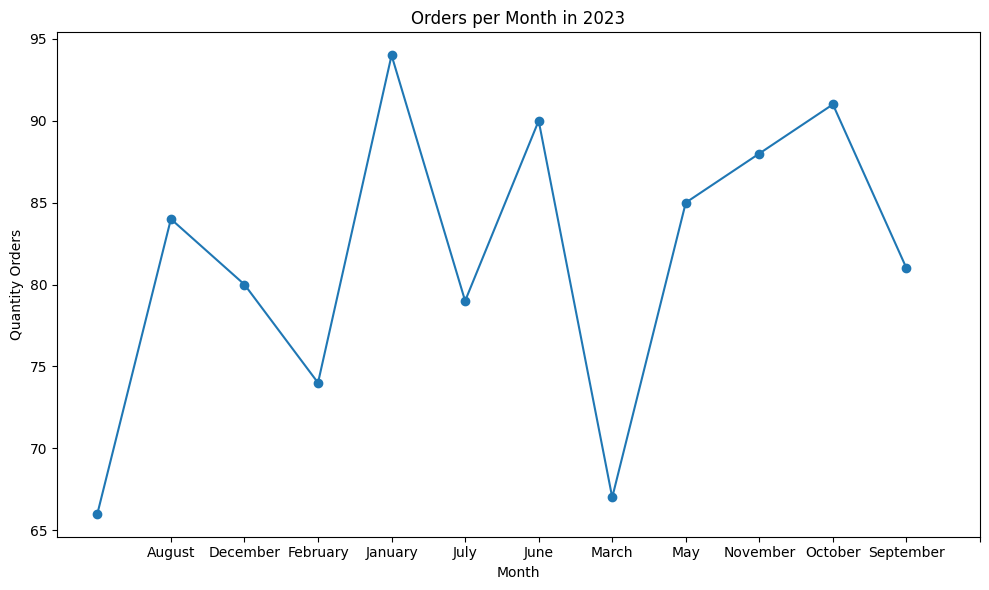

In [3]:
orders_2023 = (
    df[df["Year"] == 2023]
    .groupby("Month_name")["OrderID"]
    .nunique()
)


plt.figure(figsize=(10, 6))
plt.plot(orders_2023.index, orders_2023.values, marker="o")

plt.title("Orders per Month in 2023")
plt.xlabel("Month")
plt.ylabel("Quantity Orders")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

## -Order per Day 2023 (List Percentage each Day)

- we measure to find out each day percentage to be view point the topest is the most order date to the less down step

In [4]:
daily_mean_2023 = (
    df[(df["Year"] == 2023) & (df["Shipping Status"] == "Delivered")]
    .groupby("Day")["OrderID"]
    .nunique()
    .sort_values(ascending=False)
)

print(daily_mean_2023)

Day
16    15
27    14
7     14
2     13
8     13
12    12
14    12
23    12
22    12
21    12
26    12
1     12
3     11
4     11
6     10
18    10
13    10
24    10
29     9
5      9
19     9
17     9
11     9
25     9
20     8
10     7
15     6
28     6
9      5
30     4
31     4
Name: OrderID, dtype: int64


จากข้อมูล เราเห็นได้ว่า วันที่ 12 ,22, 7, 31 คือ วันที่มีการ orders มากที่สุด ของปี 2023 ซึ่งวัดจากค่าเฉลี่ย  เพื่อ วิเคราะห์เบื้องลึกต่อไป ซึ่ง เดือนที่มากที่สุด คือ มกราคม, 

##### ด่านล่างคือ จํานวนเดือน ของ ปี2023 - 2024 ซึ่ง ปี 2024 มีเดือนไม่ครบ และ ต้องวิเคราะห์เจาะจง เช่น เทียบเดือน กับ เดือนเดียวกัน ของปี ก่อน และ อาจจะ วิเคราะห์ trend ต่อได้ เพื่อไช้กับ การสร้างโมเดลทํานาย


In [15]:
df.groupby("Year")["Month_name"].unique().apply(sorted)

Year
2023    [April, August, December, February, January, J...
2024                                            [January]
Name: Month_name, dtype: object

In [16]:
df.groupby(["Year", "Month_name"])["Order Date"].nunique()

Year  Month_name
2023  April         27
      August        27
      December      27
      February      27
      January       31
      July          29
      June          29
      March         28
      May           29
      November      30
      October       27
      September     28
2024  January        1
Name: Order Date, dtype: int64

ความไม่เหมาะสม เราไม่สามารถวสิเคราะห์ของ ปี 2024 แล้ว และ อาจจะตัดทิ้งได้ด้วยซํ้า เพราะ ขนาด Data size ของปี 2024 ไม่มีประโยชน์ มี แค่ 1 วัน ซึ่ง เราสามารถ ตัดทิ้ง หรือ ปล่อยผ่านได้เลย และ ต่อไปของ การวิเคราะห์ เรา จะ วิเคราะห์ได้ แค่ ของ ปี2023 เท่านั้น